# Guided Numeric Exploration — GTA V Sales & Player Analytics
_Platform, region, monetization, and holiday lifts in a synthetic 2013–2026 commercial panel_

***

**Programming Language:** Python in the Jupyter Notebook Environment

**Dataset:** [crystalbaby/gta-v-worldwide-sales-and-player-analytics](https://www.kaggle.com/datasets/crystalbaby/gta-v-worldwide-sales-and-player-analytics)

**Style counterpart:** [Guided Numeric and Text Exploration — E-Commerce](https://www.kaggle.com/code/nicapotato/guided-numeric-and-text-exploration-e-commerce)

**Code Navigation:** <br>
In the code, text after hashtags (`#`) are supportive explanations, not executed as code.

***


# Tables of Content:

**1. [Introduction](#Introduction)** <br>
**2. [Setup and Data Peek](#Setup)** <br>
**3. [Univariate Snapshot](#Univariate)** <br>
**4. [Time Series Aggregates](#TimeSeries)** <br>
**5. [Platform × Year Heatmaps](#PlatformYear)** <br>
**6. [Region / Country Ladders](#Geo)** <br>
**7. [Monetization by Release Phase](#Monetization)** <br>
**8. [Holiday & Event Lifts](#Holiday)** <br>
**9. [Multivariate Association (RF)](#Association)** <br>
**10. [What It Means — Working Synthesis](#Synthesis)** <br>

# **1. Introduction:** <a id="Introduction"></a> <br>
This is a **synthetic** commercial panel for GTA V (2013–2026): country-month-platform rows with units, revenue, ASP, digital mix, estimated players, DLC/Shark Card revenue, holidays, and release phase. Treat patterns as generator properties, not Rockstar filings.

Constant column `top_game_category` (= Action-Adventure) is dropped after the peek.


# **2. Setup and Data Peek:** <a id="Setup"></a>


In [1]:
# General
import numpy as np
import pandas as pd
from pathlib import Path

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

# Scientific / modeling helpers
from IPython.display import display
from scipy import stats
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

import kagglehub

# Set Plot Theme (same family as the e-commerce guided notebook)
sns.set_palette([
    "#30a2da",
    "#fc4f30",
    "#e5ae38",
    "#6d904f",
    "#8b8b8b",
])
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (11, 5)

# Warnings
import warnings
warnings.filterwarnings("ignore")

# Wide table inspection in Jupyter cell outputs
pd.set_option("display.max_columns", 999)
pd.set_option("display.width", 220)


**Code Explanation and Reasoning:** <br>
These packages fall into three buckets: *General*, *Visualization*, and *Scientific / modeling helpers*.

`pandas` / `numpy` hold the table; `matplotlib` / `seaborn` do the graphics; `scipy` and `sklearn` support light associational checks (correlations, RandomForest importances, optional PCA/clustering), not a production model. `kagglehub` resolves files both on Kaggle (`/kaggle/input/...`) and locally.

The five-color palette matches the guided e-commerce notebook so sequential plots feel like one continuous exploration.


In [2]:
# Read and Peak at Data
CSV_BASENAME = "gta_v_worldwide_sales_player_analytics_2013_2026.csv"
KAGGLE_SLUG = "crystalbaby/gta-v-worldwide-sales-and-player-analytics"
EXPECTED_COLS = [
    "transaction_id", "year", "month", "quarter", "country", "iso3_code", "region", "platform",
    "game_edition", "sales_channel", "retailer", "units_sold", "gross_revenue_usd",
    "average_selling_price_usd", "discount_percentage", "digital_sales_percentage",
    "physical_sales_percentage", "new_customers", "returning_customers", "estimated_active_players",
    "peak_concurrent_players", "online_players", "story_mode_players", "gta_online_players",
    "dlc_revenue_usd", "shark_card_revenue_usd", "average_playtime_hours",
    "average_session_length_minutes", "holiday_season", "major_sale_event", "marketing_campaign",
    "customer_rating", "review_count", "refund_rate_percentage", "currency", "exchange_rate_to_usd",
    "internet_penetration_percentage", "gaming_market_size", "population_millions",
    "gdp_per_capita_usd", "release_phase", "weekend_sales_percentage", "weekday_sales_percentage",
    "season", "special_event", "top_game_category", "platform_generation",
]
PHASE_ORDER = ["Launch", "Growth", "Mature", "Legacy"]


def resolve_csv_path(basename: str = CSV_BASENAME) -> Path:
    kaggle_root = Path("/kaggle/input")
    if kaggle_root.exists():
        for p in kaggle_root.rglob(basename):
            return p
    local_data = Path("data") / basename
    if local_data.exists():
        return local_data
    root = Path(kagglehub.dataset_download(KAGGLE_SLUG))
    p = root / basename
    if not p.exists():
        hits = list(root.rglob(basename))
        assert hits, f"expected {basename} under {root}"
        p = hits[0]
    return p


csv_path = resolve_csv_path()
print("CSV:", csv_path)
raw = pd.read_csv(csv_path, low_memory=False)
missing = set(EXPECTED_COLS) - set(raw.columns)
assert not missing, f"missing columns: {sorted(missing)}"
assert len(raw) == 14780, f"expected 14780 rows, got {len(raw)}"
assert raw.shape[1] == 47, f"expected 47 cols, got {raw.shape[1]}"
assert raw["top_game_category"].nunique() == 1, "expected constant top_game_category"

df = raw.drop(columns=["top_game_category"]).copy()
df["release_phase"] = pd.Categorical(df["release_phase"], categories=PHASE_ORDER, ordered=True)
df["year_month"] = pd.to_datetime(df["year"].astype(str) + "-" + df["month"].astype(str).str.zfill(2) + "-01")

print("Dropped constant column: top_game_category")
print("Nulls (major_sale_event / special_event expected):", int(df.isnull().sum().sum()))
print("Dataframe Dimension: {} Rows, {} Columns".format(*df.shape))
print("Year range:", int(df["year"].min()), "→", int(df["year"].max()))
display(df.sample(5, random_state=7))


CSV: /kaggle/input/datasets/crystalbaby/gta-v-worldwide-sales-and-player-analytics/gta_v_worldwide_sales_player_analytics_2013_2026.csv
Dropped constant column: top_game_category
Nulls (major_sale_event / special_event expected): 6776
Dataframe Dimension: 14780 Rows, 47 Columns
Year range: 2013 → 2026


,transaction_id,year,month,quarter,country,iso3_code,region,platform,game_edition,sales_channel,retailer,units_sold,gross_revenue_usd,average_selling_price_usd,discount_percentage,digital_sales_percentage,physical_sales_percentage,new_customers,returning_customers,estimated_active_players,peak_concurrent_players,online_players,story_mode_players,gta_online_players,dlc_revenue_usd,shark_card_revenue_usd,average_playtime_hours,average_session_length_minutes,holiday_season,major_sale_event,marketing_campaign,customer_rating,review_count,refund_rate_percentage,currency,exchange_rate_to_usd,internet_penetration_percentage,gaming_market_size,population_millions,gdp_per_capita_usd,release_phase,weekend_sales_percentage,weekday_sales_percentage,season,special_event,platform_generation,year_month
11928,GTA5-111974,2024,1,1,Cyprus,CYP,Europe,PS4,Standard Edition,Digital,Epic Games Store,365,2237.45,6.13,59.1,68.4,31.6,124,241,11021,564,7410,3611,7410,5121.37,10345.43,15.8,38.4,1,New Year Sale,1,4.52,8,3.43,EUR,0.8981,98.0,0.48,0.97,30610.85,Legacy,40.3,59.7,Winter,New Year Sale,Gen8,2024-01-01
5840,GTA5-105831,2018,9,3,South Africa,ZAF,Africa,PC,Criminal Enterprise Starter Pack,Digital,Rockstar Games Launcher,946,20083.58,21.23,29.2,71.2,28.8,481,465,36518,2690,20760,15758,20760,10935.04,28745.09,15.7,52.7,0,Xbox Sale,1,4.41,14,1.53,ZAR,18.9450,98.0,27.38,56.39,8428.78,Mature,41.4,58.6,Autumn,Xbox Sale,PC,2018-09-01
3001,GTA5-102997,2016,4,2,Finland,FIN,Europe,PC,Premium Edition,Digital,Steam,427,12805.73,29.99,0.0,70.7,29.3,210,217,26423,1494,17522,8901,17522,12794.19,26123.19,16.0,36.9,0,NaN,0,4.50,10,3.18,EUR,0.9086,98.0,14.73,5.60,51380.58,Mature,48.2,51.8,Spring,NaN,PC,2016-04-01
7805,GTA5-107801,2020,6,2,Ghana,GHA,Africa,Xbox One,Standard Edition,Digital,Microsoft Store,296,3442.48,11.63,41.8,58.3,41.7,136,160,10324,792,6070,4254,6070,2062.96,6301.53,14.8,44.6,0,Steam Summer Sale,1,4.55,8,2.66,GHS,12.0084,98.0,1.44,28.20,2665.52,Mature,51.0,49.0,Summer,Steam Summer Sale,Gen8,2020-06-01
3397,GTA5-103410,2016,8,3,Iceland,ISL,Europe,PC,Premium Edition,Digital,Microsoft Store,263,5149.54,19.58,34.7,66.0,34.0,130,133,8852,683,5576,3276,5576,1965.25,7671.13,13.1,40.0,0,Rockstar Sale,1,4.66,4,3.05,ISK,139.6309,98.0,0.36,0.34,54815.28,Mature,37.5,62.5,Summer,Rockstar Sale,PC,2016-08-01


**Code Explanation and Reasoning:** <br>
Schema and 14,780×47 shape are asserted. `top_game_category` is constant (Action-Adventure) and dropped. `release_phase` is ordered Launch→Legacy; `year_month` supports time aggregates.


In [3]:
unique_count = [[c, df[c].nunique(dropna=False), int(df[c].isnull().sum())] for c in df.columns]
display(pd.DataFrame(unique_count, columns=["Column", "Unique", "Null"]).sort_values("Unique", ascending=False).head(25))
df[["units_sold", "gross_revenue_usd", "average_selling_price_usd", "estimated_active_players",
    "dlc_revenue_usd", "shark_card_revenue_usd", "gdp_per_capita_usd"]].describe().round(2)


,Column,Unique,Null
0,transaction_id,14780,0
25,shark_card_revenue_usd,14762,0
39,gdp_per_capita_usd,14754,0
24,dlc_revenue_usd,14727,0
12,gross_revenue_usd,14548,0
19,estimated_active_players,12993,0
23,gta_online_players,12220,0
21,online_players,12176,0
35,exchange_rate_to_usd,11106,0
22,story_mode_players,10474,0


,units_sold,gross_revenue_usd,average_selling_price_usd,estimated_active_players,dlc_revenue_usd,shark_card_revenue_usd,gdp_per_capita_usd
count,14780.00,14780.00,14780.00,14780.00,14780.00,14780.00,14780.00
mean,850.44,11571.72,15.11,31627.42,13797.62,35197.21,25814.49
std,993.34,13668.03,6.88,32668.94,16005.49,38429.45,24690.14
min,23.00,176.00,3.00,1598.00,428.16,1371.12,606.78
25%,272.00,3761.28,9.76,11468.00,4481.75,11939.22,6710.67
50%,522.00,7262.90,13.52,21072.50,8692.67,22698.03,16690.35
75%,1029.00,13845.24,18.71,39650.00,16725.82,43560.38,43135.32
max,11130.00,167483.25,39.99,330204.00,249320.44,462276.75,120894.83


**Interpretation** <br>
Units and revenue are right-skewed commercial outcomes. Nulls concentrate in optional event labels (`major_sale_event`, `special_event`). Platform, region, and release phase are the structural axes.


# **3. Univariate Snapshot:** <a id="Univariate"></a>


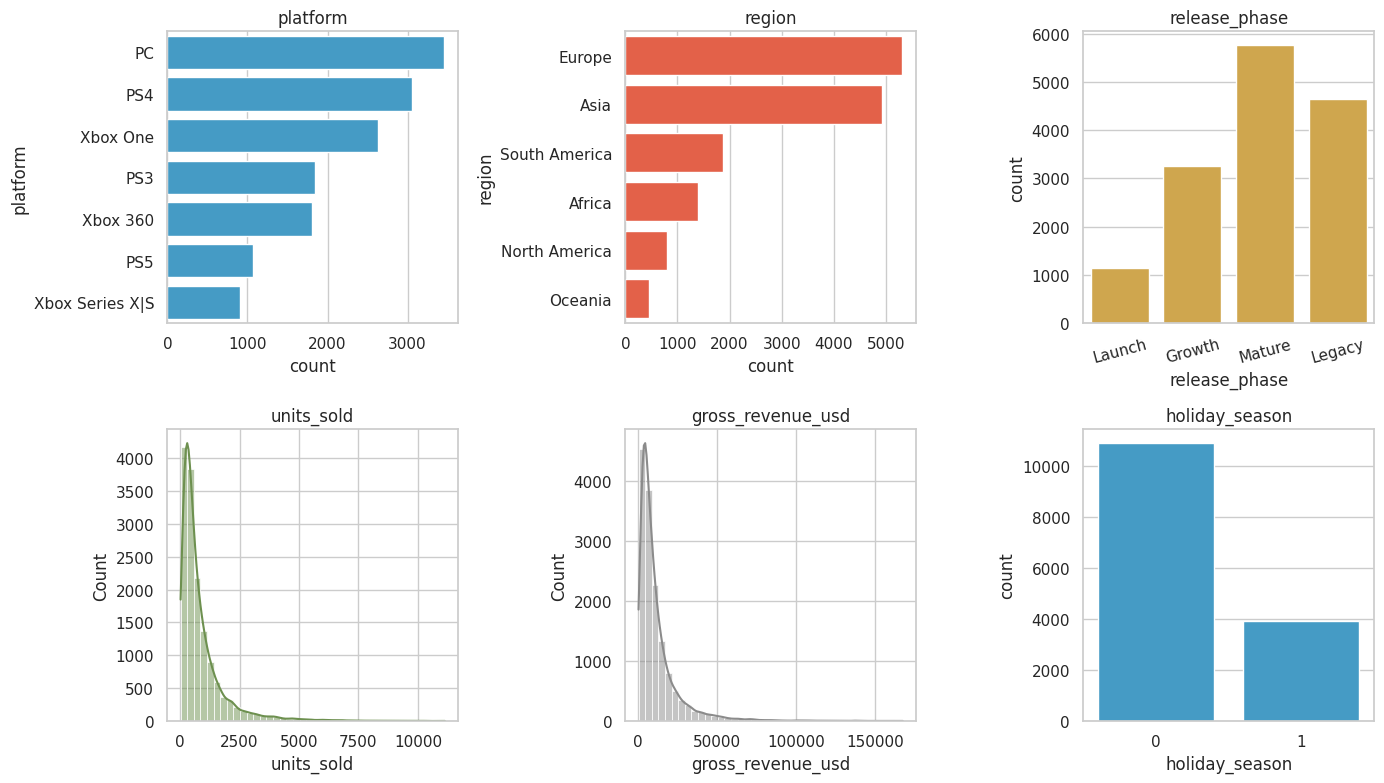

In [4]:
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.ravel()
sns.countplot(data=df, y="platform", order=df["platform"].value_counts().index, ax=axes[0], color="#30a2da")
axes[0].set_title("platform")
sns.countplot(data=df, y="region", order=df["region"].value_counts().index, ax=axes[1], color="#fc4f30")
axes[1].set_title("region")
sns.countplot(data=df, x="release_phase", order=PHASE_ORDER, ax=axes[2], color="#e5ae38")
axes[2].set_title("release_phase")
axes[2].tick_params(axis="x", rotation=15)
sns.histplot(df["units_sold"], bins=40, kde=True, ax=axes[3], color="#6d904f")
axes[3].set_title("units_sold")
sns.histplot(df["gross_revenue_usd"], bins=40, kde=True, ax=axes[4], color="#8b8b8b")
axes[4].set_title("gross_revenue_usd")
sns.countplot(data=df, x="holiday_season", ax=axes[5], color="#30a2da")
axes[5].set_title("holiday_season")
plt.tight_layout()
plt.show()


**Interpretation** <br>
PC/PS4/Xbox One dominate row counts; Europe and Asia lead region volume. Mature/Legacy phases outweigh Launch — expected for a long-tail title spanning 2013–2026.


# **4. Time Series Aggregates:** <a id="TimeSeries"></a>


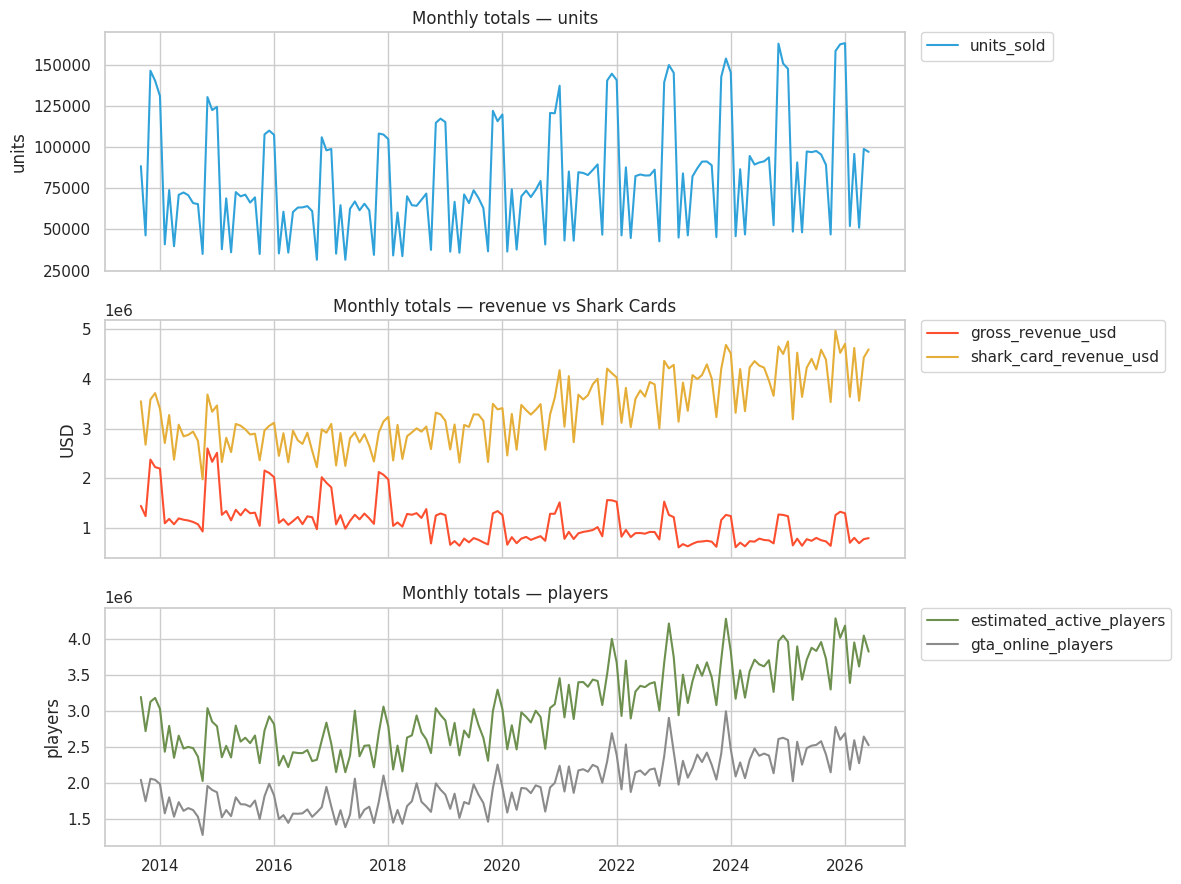

In [5]:
ts = df.groupby("year_month").agg(
    units=("units_sold", "sum"),
    revenue=("gross_revenue_usd", "sum"),
    players=("estimated_active_players", "sum"),
    online=("gta_online_players", "sum"),
    shark=("shark_card_revenue_usd", "sum"),
).reset_index()

fig, axes = plt.subplots(3, 1, figsize=(12, 9), sharex=True)
axes[0].plot(ts["year_month"], ts["units"], color="#30a2da", label="units_sold")
axes[0].set_ylabel("units")
axes[0].legend(bbox_to_anchor=(1.02, 1), loc="upper left", borderaxespad=0)
axes[0].set_title("Monthly totals — units")
axes[1].plot(ts["year_month"], ts["revenue"], color="#fc4f30", label="gross_revenue_usd")
axes[1].plot(ts["year_month"], ts["shark"], color="#e5ae38", label="shark_card_revenue_usd")
axes[1].set_ylabel("USD")
axes[1].legend(bbox_to_anchor=(1.02, 1), loc="upper left", borderaxespad=0)
axes[1].set_title("Monthly totals — revenue vs Shark Cards")
axes[2].plot(ts["year_month"], ts["players"], color="#6d904f", label="estimated_active_players")
axes[2].plot(ts["year_month"], ts["online"], color="#8b8b8b", label="gta_online_players")
axes[2].set_ylabel("players")
axes[2].legend(bbox_to_anchor=(1.02, 1), loc="upper left", borderaxespad=0)
axes[2].set_title("Monthly totals — players")
plt.tight_layout()
plt.show()


**Interpretation** <br>
Monthly sums reveal launch spikes, platform-generation waves, and whether Shark Card revenue tracks or decouples from boxed/digital units over the Legacy years.


# **5. Platform × Year Heatmaps:** <a id="PlatformYear"></a>


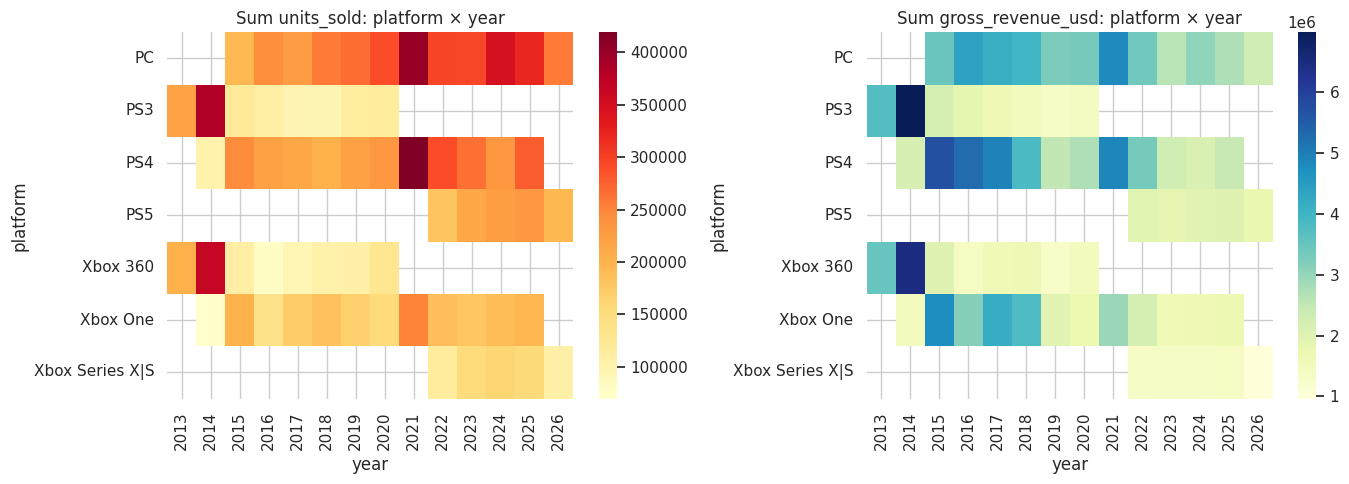

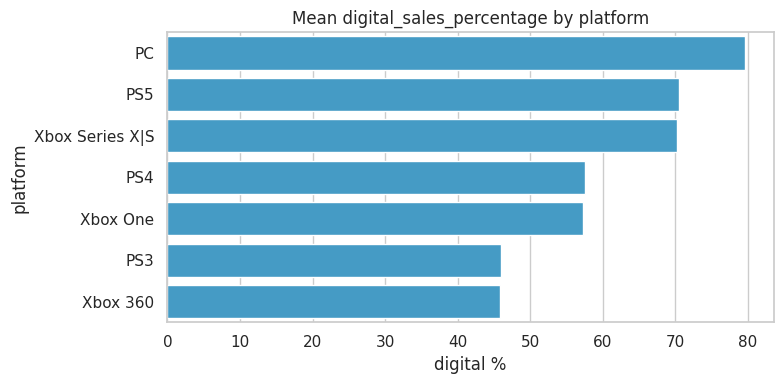

In [6]:
plat_year_units = df.pivot_table(index="platform", columns="year", values="units_sold", aggfunc="sum")
plat_year_rev = df.pivot_table(index="platform", columns="year", values="gross_revenue_usd", aggfunc="sum")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.heatmap(plat_year_units, cmap="YlOrRd", ax=axes[0])
axes[0].set_title("Sum units_sold: platform × year")
sns.heatmap(plat_year_rev, cmap="YlGnBu", ax=axes[1])
axes[1].set_title("Sum gross_revenue_usd: platform × year")
plt.tight_layout()
plt.show()

# Digital mix by platform
dig = df.groupby("platform")["digital_sales_percentage"].mean().sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(8, 4))
sns.barplot(x=dig.values, y=dig.index, ax=ax, color="#30a2da")
ax.set_title("Mean digital_sales_percentage by platform")
ax.set_xlabel("digital %")
plt.tight_layout()
plt.show()


**Interpretation** <br>
Platform×year heatmaps show generation handoffs (PS3/360 → PS4/One → PS5/Series). Digital share by platform asks whether PC rows are systematically more digital.


# **6. Region / Country Ladders:** <a id="Geo"></a>


,units,revenue,asp,gdp
region,,,,
Europe,4820477,66413793.74,15.31,37984.92
Asia,3802483,51836436.70,15.21,19427.01
North America,1990506,26479815.16,14.45,43222.23
South America,906262,11961653.70,14.44,12996.23
Africa,590389,8087772.16,15.26,4192.92
Oceania,459349,6250513.49,15.15,40663.19


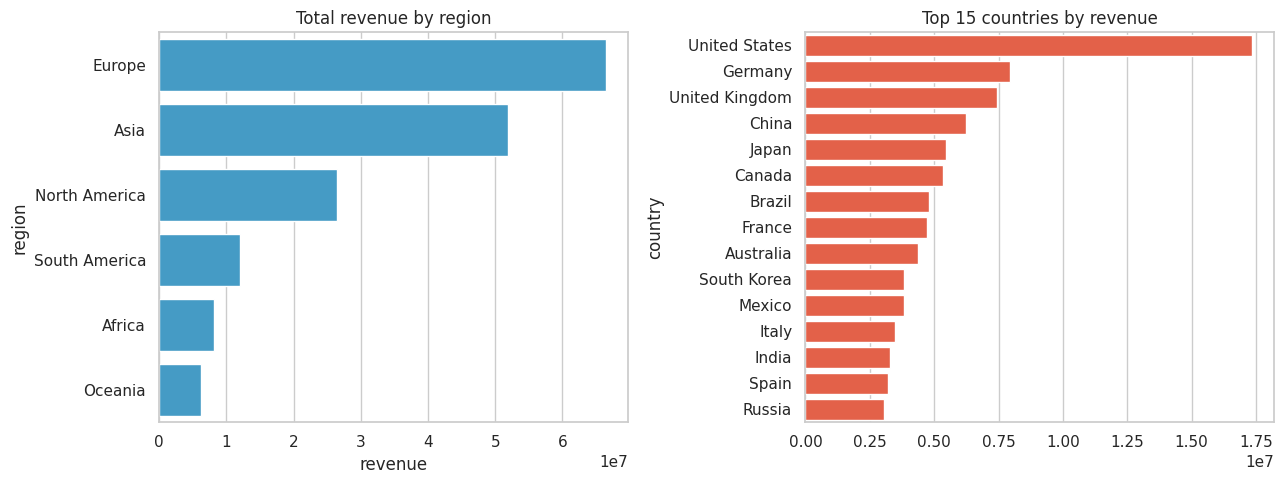

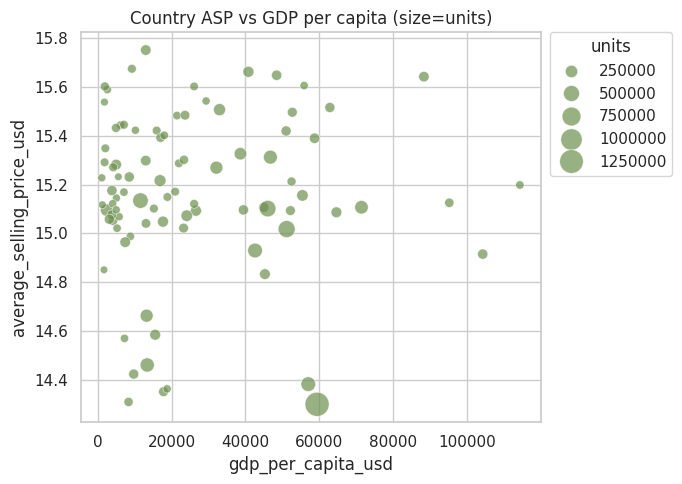

In [7]:
reg = df.groupby("region").agg(
    units=("units_sold", "sum"),
    revenue=("gross_revenue_usd", "sum"),
    asp=("average_selling_price_usd", "mean"),
    gdp=("gdp_per_capita_usd", "mean"),
).sort_values("revenue", ascending=False)
display(reg.round(2))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sns.barplot(data=reg.reset_index(), x="revenue", y="region", ax=axes[0], color="#30a2da")
axes[0].set_title("Total revenue by region")
top_c = (
    df.groupby("country")["gross_revenue_usd"].sum().sort_values(ascending=False).head(15)
)
sns.barplot(x=top_c.values, y=top_c.index, ax=axes[1], color="#fc4f30")
axes[1].set_title("Top 15 countries by revenue")
plt.tight_layout()
plt.show()

# GDP vs ASP (country aggregates)
cagg = df.groupby("country").agg(
    asp=("average_selling_price_usd", "mean"),
    gdp=("gdp_per_capita_usd", "mean"),
    units=("units_sold", "sum"),
).reset_index()
fig, ax = plt.subplots(figsize=(7, 5))
sns.scatterplot(data=cagg, x="gdp", y="asp", size="units", sizes=(30, 300), alpha=0.7, ax=ax, color="#6d904f")
ax.set_title("Country ASP vs GDP per capita (size=units)")
ax.set_xlabel("gdp_per_capita_usd")
ax.set_ylabel("average_selling_price_usd")
# size legend outside
h, lab = ax.get_legend_handles_labels()
ax.legend(h, lab, title="units", bbox_to_anchor=(1.02, 1), loc="upper left", borderaxespad=0)
plt.tight_layout()
plt.show()


**Interpretation** <br>
Region and country ladders show where the generator concentrates commercial volume. ASP vs GDP checks whether richer markets price higher — or whether discounts wash it out.


# **7. Monetization by Release Phase:** <a id="Monetization"></a>


,gross,shark_share,dlc_share,online_share,story_share
release_phase,,,,,
Launch,15866973.65,2.496,0.966,20269.263,11047.855
Growth,37390486.86,2.966,1.133,19746.492,10589.612
Mature,70430143.19,2.472,0.994,17895.044,9440.213
Legacy,47342381.25,4.132,1.609,24794.038,13122.089


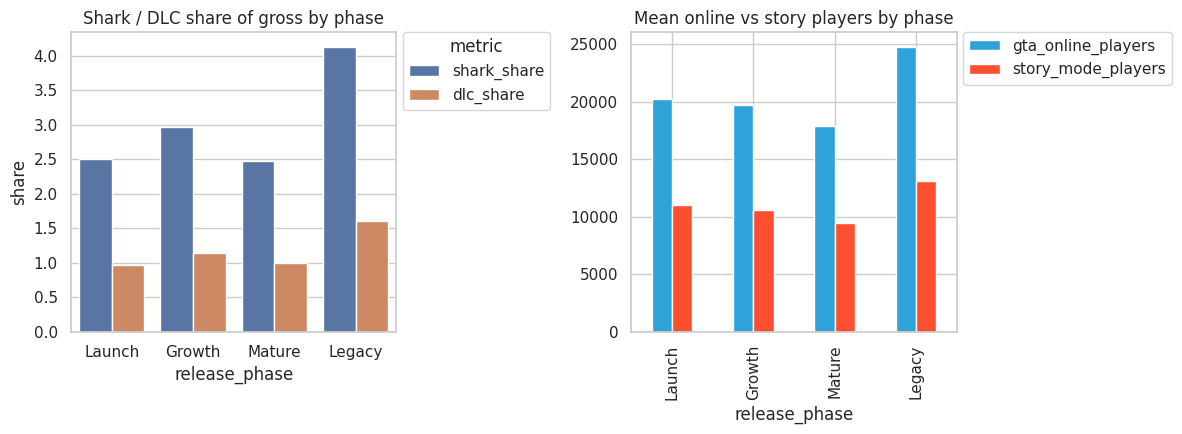

In [8]:
# Shark / DLC shares of gross revenue by release phase
mon = df.groupby("release_phase", observed=True).agg(
    gross=("gross_revenue_usd", "sum"),
    shark=("shark_card_revenue_usd", "sum"),
    dlc=("dlc_revenue_usd", "sum"),
    units=("units_sold", "sum"),
    online_share=("gta_online_players", "mean"),
    story_share=("story_mode_players", "mean"),
).reindex(PHASE_ORDER)
mon["shark_share"] = mon["shark"] / mon["gross"]
mon["dlc_share"] = mon["dlc"] / mon["gross"]
display(mon[["gross", "shark_share", "dlc_share", "online_share", "story_share"]].round(3))

plot_m = mon.reset_index().melt(
    id_vars="release_phase", value_vars=["shark_share", "dlc_share"],
    var_name="metric", value_name="share",
)
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
sns.barplot(data=plot_m, x="release_phase", y="share", hue="metric", order=PHASE_ORDER, ax=axes[0])
axes[0].set_title("Shark / DLC share of gross by phase")
axes[0].legend(title="metric", bbox_to_anchor=(1.02, 1), loc="upper left", borderaxespad=0)
player = df.groupby("release_phase", observed=True)[["gta_online_players", "story_mode_players"]].mean().reindex(PHASE_ORDER)
player.plot(kind="bar", ax=axes[1], color=["#30a2da", "#fc4f30"])
axes[1].set_title("Mean online vs story players by phase")
axes[1].legend(bbox_to_anchor=(1.02, 1), loc="upper left", borderaxespad=0)
plt.tight_layout()
plt.show()


**Interpretation** <br>
If Shark/DLC shares rise in Mature/Legacy while story-mode players fade, the generator is telling a live-service monetization story after the launch box.


# **8. Holiday & Event Lifts:** <a id="Holiday"></a>


,units_mean,rev_mean,discount_mean,n
holiday_season,,,,
0,688.41,9823.36,33.93,10880
1,1302.46,16449.19,44.96,3900


Holiday units lift (mean holiday / mean non-holiday): 1.892


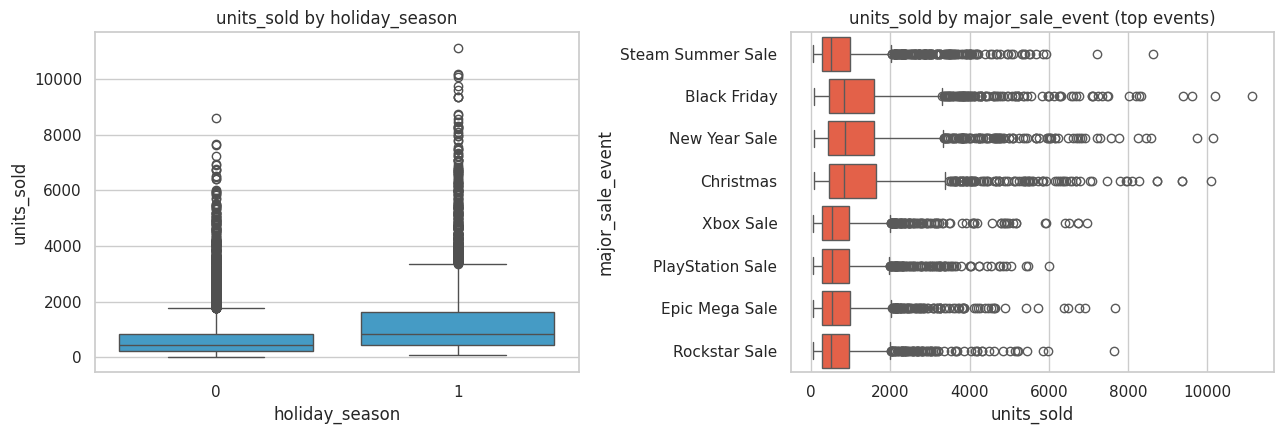

,units_sold,gross_revenue_usd
marketing_campaign,,
0,469.81,9496.53
1,961.74,12178.52


In [9]:
# Holiday season lift on units / revenue
hol = df.groupby("holiday_season").agg(
    units_mean=("units_sold", "mean"),
    rev_mean=("gross_revenue_usd", "mean"),
    discount_mean=("discount_percentage", "mean"),
    n=("transaction_id", "size"),
)
display(hol.round(2))
print("Holiday units lift (mean holiday / mean non-holiday):",
      round(hol.loc[1, "units_mean"] / hol.loc[0, "units_mean"], 3))

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
sns.boxplot(data=df, x="holiday_season", y="units_sold", ax=axes[0], color="#30a2da")
axes[0].set_title("units_sold by holiday_season")
# Major sale events (non-null)
ev = df.dropna(subset=["major_sale_event"]).copy()
top_ev = ev["major_sale_event"].value_counts().head(8).index
sns.boxplot(
    data=ev[ev["major_sale_event"].isin(top_ev)],
    y="major_sale_event", x="units_sold", order=top_ev, ax=axes[1], color="#fc4f30",
)
axes[1].set_title("units_sold by major_sale_event (top events)")
plt.tight_layout()
plt.show()

# Marketing campaign flag
mkt = df.groupby("marketing_campaign")[["units_sold", "gross_revenue_usd"]].mean()
display(mkt.round(2))


**Interpretation** <br>
Holiday and named sale events should lift mean units if the generator encodes promo calendars. Compare discount% alongside units so a 'lift' is not just deeper markdown without volume.


# **9. Multivariate Association (RF):** <a id="Association"></a>


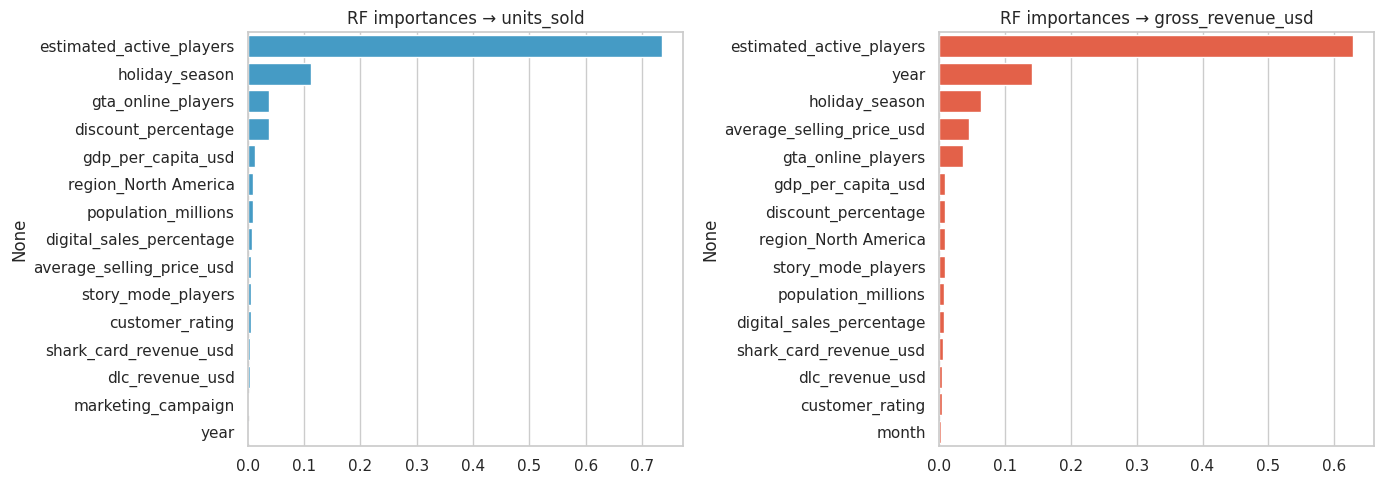

RF in-sample R^2 units: 0.979
RF in-sample R^2 revenue: 0.978


In [10]:
# RF for units_sold and gross_revenue_usd — exclude direct revenue leakage for units model
feature_num = [
    "year", "month", "average_selling_price_usd", "discount_percentage", "digital_sales_percentage",
    "estimated_active_players", "gta_online_players", "story_mode_players",
    "dlc_revenue_usd", "shark_card_revenue_usd", "holiday_season", "marketing_campaign",
    "customer_rating", "gdp_per_capita_usd", "internet_penetration_percentage", "population_millions",
]
feature_cat = ["region", "platform", "game_edition", "sales_channel", "release_phase"]

X = df[feature_num + feature_cat].copy()
# Fill event nulls for encoding — use explicit sentinel, fail if unexpected dtypes
assert X[feature_num].isnull().sum().sum() == 0

y_units = df["units_sold"]
y_rev = df["gross_revenue_usd"]
pre = ColumnTransformer([
    ("num", "passthrough", feature_num),
    ("cat", OneHotEncoder(handle_unknown="ignore"), feature_cat),
])
pipe_u = Pipeline([
    ("pre", pre),
    ("rf", RandomForestRegressor(n_estimators=200, max_depth=12, random_state=7, n_jobs=-1)),
])
pipe_u.fit(X, y_units)
rf_u = pipe_u.named_steps["rf"]
enc = pipe_u.named_steps["pre"]
names = feature_num + list(enc.named_transformers_["cat"].get_feature_names_out(feature_cat))
imp_u = pd.Series(rf_u.feature_importances_, index=names).sort_values(ascending=False).head(15)

# Revenue model: drop units-like leakage from shark/dlc? keep them as monetization inputs; drop ASP*units tautology by not including units
pipe_r = Pipeline([
    ("pre", ColumnTransformer([
        ("num", "passthrough", feature_num),
        ("cat", OneHotEncoder(handle_unknown="ignore"), feature_cat),
    ])),
    ("rf", RandomForestRegressor(n_estimators=200, max_depth=12, random_state=7, n_jobs=-1)),
])
pipe_r.fit(X, y_rev)
rf_r = pipe_r.named_steps["rf"]
enc_r = pipe_r.named_steps["pre"]
names_r = feature_num + list(enc_r.named_transformers_["cat"].get_feature_names_out(feature_cat))
imp_r = pd.Series(rf_r.feature_importances_, index=names_r).sort_values(ascending=False).head(15)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.barplot(x=imp_u.values, y=imp_u.index, ax=axes[0], color="#30a2da")
axes[0].set_title("RF importances → units_sold")
sns.barplot(x=imp_r.values, y=imp_r.index, ax=axes[1], color="#fc4f30")
axes[1].set_title("RF importances → gross_revenue_usd")
plt.tight_layout()
plt.show()
print("RF in-sample R^2 units:", round(rf_u.score(enc.transform(X), y_units), 3))
print("RF in-sample R^2 revenue:", round(rf_r.score(enc_r.transform(X), y_rev), 3))


**Interpretation** <br>
RF importances are exploratory and in-sample. Platform/phase/holiday features competing with player counts shows whether demand proxies or calendar flags dominate the generator.


# **10. What It Means — Working Synthesis:** <a id="Synthesis"></a>

**What the table is:** <br>
A synthetic 2013–2026 GTA V commercial panel (country × month × platform) with units, revenue, players, and monetization fields.

**Working takeaways:** <br>
- Constant `top_game_category` adds no information and was dropped.
- Platform×year heatmaps encode generation handoffs; Mature/Legacy phases dominate row mass.
- Shark/DLC revenue shares by release phase test the live-service shift after launch.
- Holiday and named sale events provide calendar lift checks alongside discount depth.
- RF importances for units and revenue rank structural vs monetization inputs — not causal claims.

**Open follow-ups:** <br>
- Country fixed effects for holiday lift (within-country holiday vs non-holiday).
- Shark share residualized on online-player share by phase.
- Digital mix × ASP interaction by sales_channel.
